<a href="https://colab.research.google.com/github/zeynepbykn/SMS_Spam_Tespiti_Proje/blob/main/SMS_spam_veriBilimi_proje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Veriyi Okuma ve İstatistikleri **Çıkarma**

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import requests
import io

# 1. ADIM: Veriyi doğrudan UCI sitesinden indiriyoruz (Zeynep & Kübra Ortak)
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
response = requests.get(url)

# 2. ADIM: İndirilen zip içeriğini açıyoruz
with zipfile.ZipFile(io.BytesIO(response.content), 'r') as zip_ref:
    zip_ref.extractall('sms_data') # 'sms_data' isimli bir klasöre çıkartır


df = pd.read_csv('sms_data/SMSSpamCollection', sep='\t', names=['label', 'message'])

print("Veri Seti Boyutu:", df.shape) # (5574, 2):5574 mesaj ve 2 sütun
## df.head(): Tablonun en üstündeki ilk 5 satırı ekrana getirir,kontrol etmemizi sağlar.
print("\nİlk 5 Satır:\n", df.head())

# Sınıf Dağılımı
# label sütunundaki değerleri sayar:kaç tane ham,spam mesaj oldugu yazıyor.
print("\nSınıf Sayıları:")
print(df['label'].value_counts())

Veri Seti Boyutu: (5572, 2)

İlk 5 Satır:
   label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Sınıf Sayıları:
label
ham     4825
spam     747
Name: count, dtype: int64


Görselleştirme (Grafik) **Kodları**

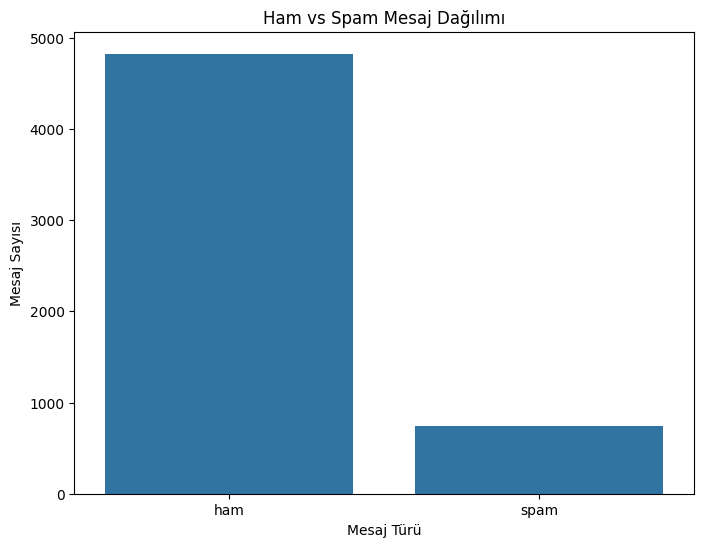

In [11]:
# Grafiğin boyutu: (8 birim genişlik, 6 birim yükseklik).
plt.figure(figsize=(8,6))

# sns.countplot: Kategorik veriler için (ham/spam) sütun grafiği çizer.
# x='label': Alt eksende etiketler (ham ve spam) yer alacak.
sns.countplot(x='label', data=df)

# Grafiğe başlık ve eksen isimleri ekliyoruz.
plt.title('Ham vs Spam Mesaj Dağılımı') # Grafiğin ana başlığı.
plt.xlabel('Mesaj Türü') # Yatay eksen ismi.
plt.ylabel('Mesaj Sayısı') # Dikey eksen ismi.

# plt.show ile grafiği çizer
plt.show()

# Veri Temizliği(NLP Preprocessing)

In [12]:
import string
import nltk
from nltk.corpus import stopwords

# Gerekli paketleri indiriyoruz
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def temizle(metin):
    metin = metin.lower() # Hepsini kucuk harfe çevirir.
    metin = ''.join([char for char in metin if char not in string.punctuation]) # Noktalama işaretlerini kaldırır.
    metin = ''.join([char for char in metin if not char.isdigit()]) # Sayıları kaldırır.
    metin = ' '.join([kelime for kelime in metin.split() if kelime not in stop_words]) # Stopwords(the,is,and..)
    return metin

# Temizlemeden önce orijinal uzunluğu ölçelim
df['mesaj_uzunluk'] = df['message'].apply(len)
#spam mesajlar genelde daha uzundur.

# Temizleme işlemini uygulayalım
df['temiz_mesaj'] = df['message'].apply(temizle)

print("Temizleme işlemi tamamlandı!")
print("\n--- Makale İçin Ön Analiz ---")
# Spam ve Ham mesajların uzunluk farkını görelim
print(df.groupby('label')['mesaj_uzunluk'].mean())

Temizleme işlemi tamamlandı!

--- Makale İçin Ön Analiz ---
label
ham      71.482487
spam    138.670683
Name: mesaj_uzunluk, dtype: float64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# TF-IDF (Kelime Ağırlıgı Hesaplama)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF nesnesini oluşturuyoruz
# max_features=3000: En önemli 3000 kelimeyi alıyoruz(tum kelimeleri alırsak gurultu katabilir,modelin kafası karışabilir)
tfidf = TfidfVectorizer(max_features=3000)

# Temizlenmiş mesajlarımızı sayılara dönüştürüyoruz(Çunku model sayılardan anlıyor.)
X = tfidf.fit_transform(df['temiz_mesaj']).toarray()

# Hedef değişkenimizi (spam mi ham mi) sayısallaştırıyoruz
# ham = 0, spam = 1
y = df['label'].map({'ham': 0, 'spam': 1}).values

print("Vektörleştirme Tamamlandı!")
print("X (Girdi) Boyutu:", X.shape) # (5572, 3000) gibi bir sonuç gelmeli

Vektörleştirme Tamamlandı!
X (Girdi) Boyutu: (5572, 3000)


# Eğitim ve Test Olarak Bölme

In [14]:
from sklearn.model_selection import train_test_split

# Verinin %20'sini test (sınav), %80'ini eğitim (ders çalışma) için ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Eğitim seti (X_train) boyutu:", X_train.shape)
print("Test seti (X_test) boyutu:", X_test.shape)

Eğitim seti (X_train) boyutu: (4457, 3000)
Test seti (X_test) boyutu: (1115, 3000)


RANDOM FOREST MODELİ

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Modeli oluştur
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Modeli eğit
rf_model.fit(X_train, y_train)

# 3. Tahmin yap
y_pred_rf = rf_model.predict(X_test)

# 4. Sonuçları yazdır
print(f"Doğruluk: %{accuracy_score(y_test, y_pred_rf)*100:.2f}")

Doğruluk: %98.12


Random Forest Karmaşıklık Matrisi (Heatmap)

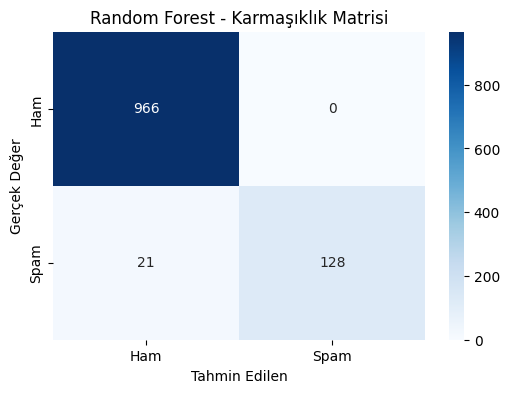

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# rf_model ve y_pred_rf isimlerini yukarıdaki kodlarına göre kontrol et
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Random Forest - Karmaşıklık Matrisi')
plt.show()

Performans Metrikleri Çubuk Grafiği

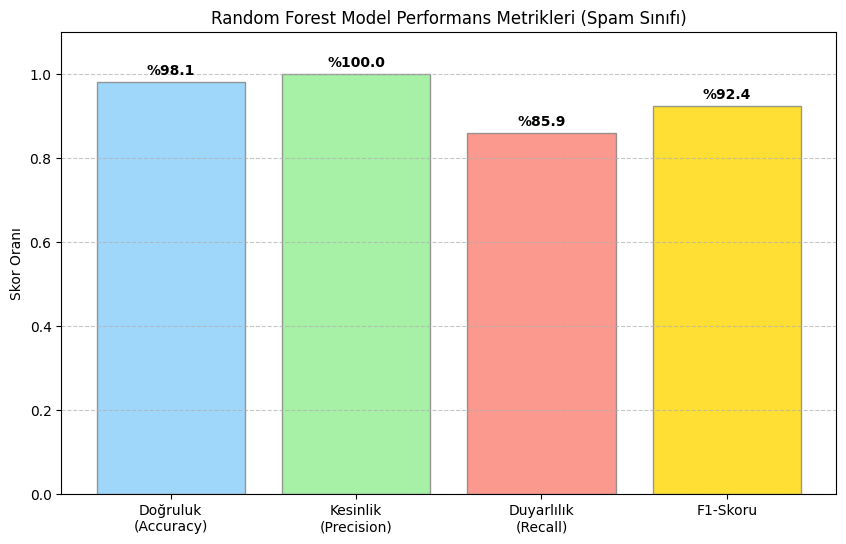

In [18]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Metrikleri hesaplayalım (Spam sınıfı için)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='binary')

metrikler = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
skorlar = [acc_rf, prec_rf, rec_rf, f1_rf]
renkler = ['lightskyblue', 'lightgreen', 'salmon', 'gold']

# Grafik çizimi
plt.figure(figsize=(10, 6))
barlar = plt.bar(metrikler, skorlar, color=renkler, edgecolor='gray', alpha=0.8)

# Çubukların üzerine yüzde değerlerini yazalım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('Random Forest Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

NAVİE BAYES **MODELİ**

In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# MultinomialNB():
# Naive Bayes'in "çok terimli" versiyonudur. TF-IDF gibi kelime sayımları ve ağırlıklarıyla çalışmak üzere tasarlanmıştır.
#  Naive Bayes modelini (Multinomial versiyonu) oluşturuyoruz
nb_model = MultinomialNB()

# Modeli eğitim verilerimizle eğitiyoruz(%80)
# X_train: (Kelime ağırlıkları), y_train: Ham/Spam (0/1)
nb_model.fit(X_train, y_train)

# Modeli teste sokuyoruz(%20 lik kısım)
y_pred = nb_model.predict(X_test)

# Başarıyı ölçüyoruz
print("--- Naive Bayes Performans Sonuçları ---")
# Modelin tahminleri (y_pred) ile gerçek cevapları (y_test) karşılaştırır.
print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

--- Naive Bayes Performans Sonuçları ---
Doğruluk (Accuracy) Skoru: %98.03

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



Naive Bayes Algoritması ile verisetinde duzenledigimiz her mesajdaki kelimelerin kelime ağırlıklarını bulmuştuk ve bayes bu spam mesajlarındaki geçen kelimelere bakarak bunların olasılıklarını hesaplar.Ve gelen yeni mesajın hesabını olasılık hesabı ile ham veya spamda geçme olasılıklarını çarpar.

**BAYES-Metriklerin Sütun Grafiği**

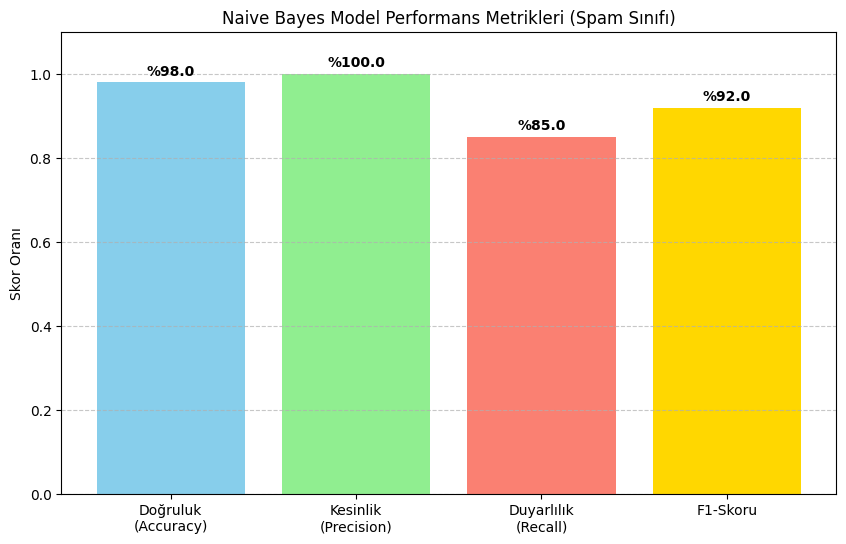

In [20]:
import matplotlib.pyplot as plt
import numpy as np

#  Metrik değerlerini bir listeye alıyoruz
metrik_isimleri = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
# Spam (1) sınıfına ait değerleri baz alıyoruz çünkü başarımızı o belirliyor
metrik_degerleri = [0.98, 1.00, 0.85, 0.92]

#  Grafik oluşturma
plt.figure(figsize=(10, 6))
renkler = ['skyblue', 'lightgreen', 'salmon', 'gold']
barlar = plt.bar(metrik_isimleri, metrik_degerleri, color=renkler)

#  Grafik üzerine değerleri (yüzdeleri) yazdıralım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

#  Grafik süslemeleri
plt.ylim(0, 1.1) # Üst sınırı biraz boş bırakalım ki sayılar görünsün
plt.ylabel('Skor Oranı')
plt.title('Naive Bayes Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Doğruluk grafiği- %98 çıktı yüksek bir deger fakat veri setimiz dengesiz oldugu için diğer grafiklere ve F1-skoru grafiğine bakmamız önemli!!


# BAYES-Karmaşıklık Matrisi

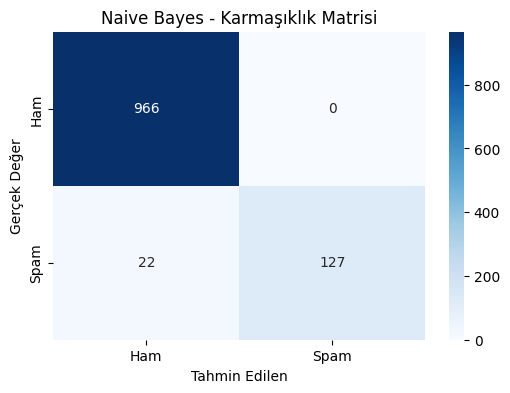

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Naive Bayes - Karmaşıklık Matrisi')
plt.show()

Sinir Ağları Modelini Eğitme ve Tahmin Yapma

In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Modeli oluşturuyoruz
# hidden_layer_sizes=(100,): Beynimizde 100 hücreli bir gizli katman var demek.
# max_iter=300: Modelin öğrenmek için veri üzerinden kaç kez geçeceğini belirler.
# random_state=42: Her çalıştırdığımızda aynı sonucu almamızı sağlar.
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)

# 2. Modeli eğitiyoruz (Öğrenme aşaması)
mlp_model.fit(X_train, y_train)

# 3. Test verisi ile tahmin yapıyoruz
y_pred_mlp = mlp_model.predict(X_test)

# 4. Genel başarıyı yazdıralım
print("--- Kübra'nın Sinir Ağları (MLP) Sonuçları ---")
print(f"Doğruluk (Accuracy): %{accuracy_score(y_test, y_pred_mlp)*100:.2f}")

--- Kübra'nın Sinir Ağları (MLP) Sonuçları ---
Doğruluk (Accuracy): %98.21


Sinir Ağları Karmaşıklık Matrisi (Heatmap)

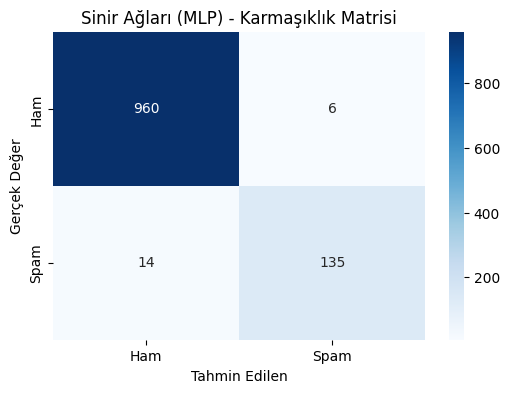

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# mlp_model ve y_pred_mlp isimlerini kontrol et
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Sinir Ağları (MLP) - Karmaşıklık Matrisi')
plt.show()

Sinir Ağları Performans Metrikleri Grafiği

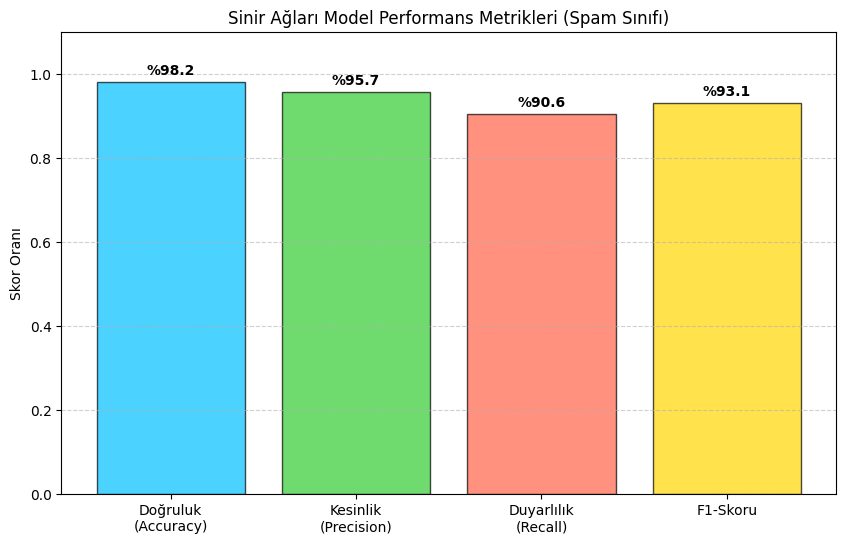

In [24]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Metrikleri hesaplayalım (Spam sınıfı için)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp, rec_mlp, f1_mlp, _ = precision_recall_fscore_support(y_test, y_pred_mlp, average='binary')

metrikler = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
skorlar = [acc_mlp, prec_mlp, rec_mlp, f1_mlp]
renkler = ['deepskyblue', 'limegreen', 'tomato', 'gold']

# Grafik çizimi
plt.figure(figsize=(10, 6))
barlar = plt.bar(metrikler, skorlar, color=renkler, edgecolor='black', alpha=0.7)

# Çubukların üzerine yüzde değerlerini yazalım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('Sinir Ağları Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

**Lojistik Regresyon**

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Modeli oluşturuyoruz
# random_state=42: Deneyi her çalıştırdığımızda aynı katsayıları bulması için
log_model = LogisticRegression(random_state=42)

# Eğitim (Ağırlık/Katsayı Öğrenme)
# Model, X_train'deki 3000 kelime ağırlığına bakarak hangi kelimenin spama,
# hangisinin hama çektiğini (katsayıları) hesaplar.
log_model.fit(X_train, y_train)
#lojistik regresyonda ağırlıklar toplanır ve sigmoid fonksiyonuna sokulup 0-1 arasına sıkıştırılır.

# Hiç görmediği test verilerini (X_test) süzgecinden (Sigmoid) geçirir.
y_pred_log = log_model.predict(X_test)
# 0.5> Spam  , 0.5 'ten kucuk ise hham kabul edilir.

# Sonuçları Yazdırma
print("--- Lojistik Regresyon Performans Sonuçları ---")
print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred_log)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_log))

--- Lojistik Regresyon Performans Sonuçları ---
Doğruluk (Accuracy) Skoru: %96.50

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



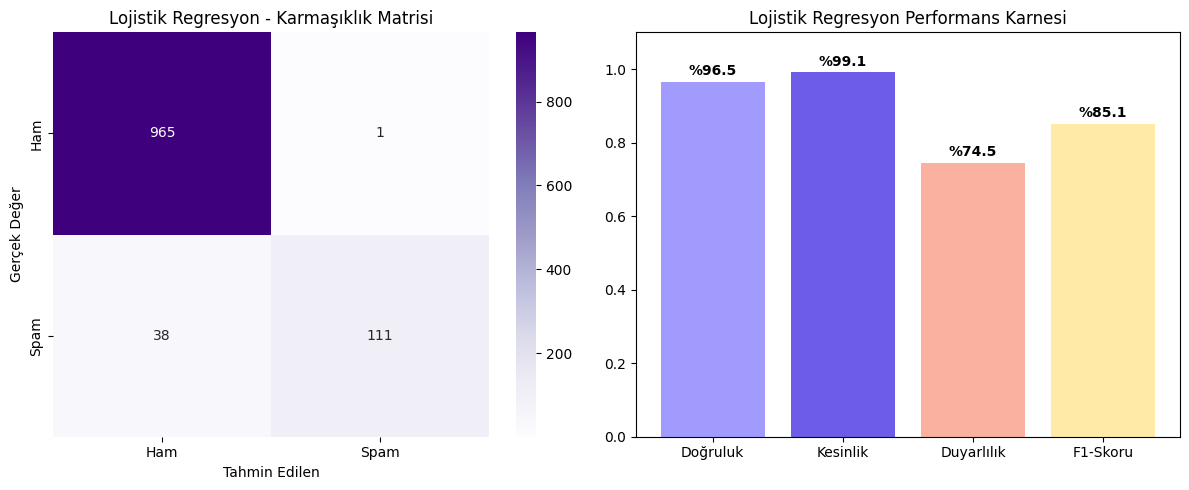

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# --- GRAFİK 1: Karmaşıklık Matrisi (Confusion Matrix) ---
plt.figure(figsize=(12, 5))

# Sol tarafa Matrisi çizelim
plt.subplot(1, 2, 1)
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Purples', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Lojistik Regresyon - Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')

# --- GRAFİK 2: Performans Metrikleri Sütun Grafiği ---
plt.subplot(1, 2, 2)
# Metrikleri hesaplayalım
acc = accuracy_score(y_test, y_pred_log)
pre = precision_score(y_test, y_pred_log)
rec = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

metrik_isimleri = ['Doğruluk', 'Kesinlik', 'Duyarlılık', 'F1-Skoru']
metrik_degerleri = [acc, pre, rec, f1]
renkler = ['#a29bfe', '#6c5ce7', '#fab1a0', '#ffeaa7']

barlar = plt.bar(metrik_isimleri, metrik_degerleri, color=renkler)
plt.ylim(0, 1.1)
plt.title('Lojistik Regresyon Performans Karnesi')

# Çubukların üzerine değerleri yazdıralım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

KNN Modelini Eğitme ve Tahmin Yapma

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# n_neighbors=5: En yakın 5 komşuya bakarak karar ver demek.
# metric='euclidean': Aradaki mesafeyi kuş uçuşu (Öklid) olarak ölçer.
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# 2. Modeli eğitiyoruz
knn_model.fit(X_train, y_train)

# 3. Test verisi ile tahmin yapıyoruz
y_pred_knn = knn_model.predict(X_test)

# 4. Genel başarıyı yazdıralım
print("En Yakın Komşu Sonuçları ---")
print(f"Doğruluk (Accuracy): %{accuracy_score(y_test, y_pred_knn)*100:.2f}")

En Yakın Komşu Sonuçları ---
Doğruluk (Accuracy): %92.47


KNN Karmaşıklık Matrisi (Heatmap)

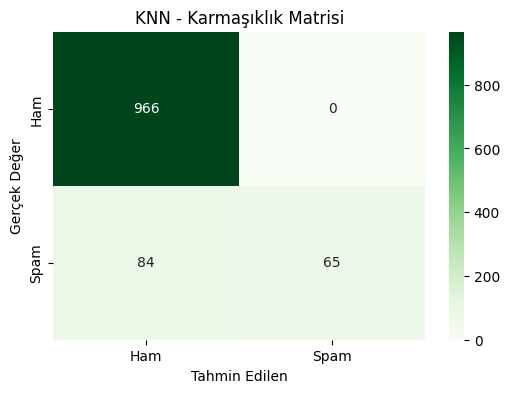

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Karmaşıklık matrisini hesapla
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Görselleştirme
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', # KNN için yeşil tonları
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('KNN - Karmaşıklık Matrisi')
plt.show()

KNN Başarı Metrikleri (Renkli Çubuk Grafiği)

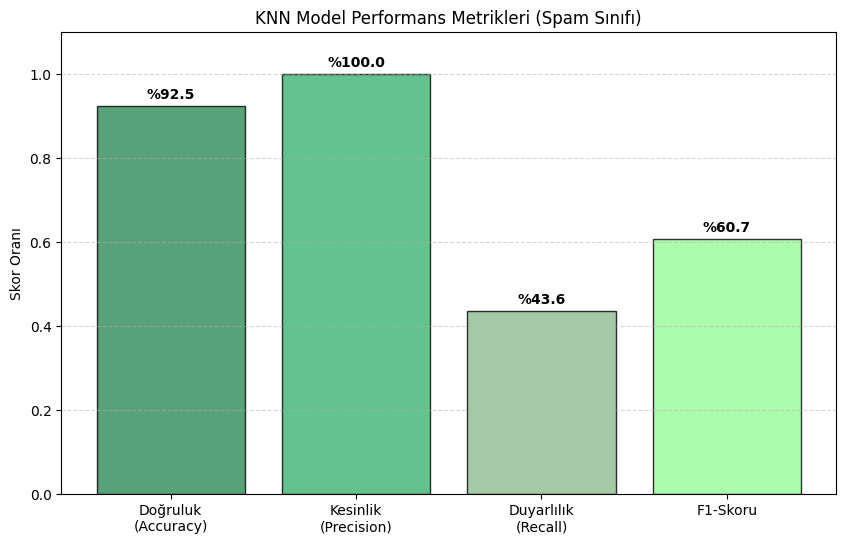

In [29]:
from sklearn.metrics import precision_recall_fscore_support

# Başarı oranlarını (Precision, Recall, F1) hesaplıyoruz
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn, rec_knn, f1_knn, _ = precision_recall_fscore_support(y_test, y_pred_knn, average='binary')

metrikler = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
skorlar = [acc_knn, prec_knn, rec_knn, f1_knn]
renkler = ['#2e8b57', '#3cb371', '#8fbc8f', '#98fb98'] # Yeşil tonları

plt.figure(figsize=(10, 6))
barlar = plt.bar(metrikler, skorlar, color=renkler, edgecolor='black', alpha=0.8)

# Çubukların üzerine yüzde yazılarını ekle
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}',
             ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('KNN Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()